In [1]:
# STEP 1: Import Libraries
import os
import zipfile
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
# STEP 2: Download the Dataset
url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
zip_path = "cats_and_dogs_filtered.zip"

import requests

print("Downloading dataset...")
r = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(r.content)

print("Download complete!")
print("Saved as:", zip_path)


Download complete!
Saved as: cats_and_dogs_filtered.zip


In [4]:
!wget https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip -O cats_and_dogs_filtered.zip


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
import requests

url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
zip_path = "cats_and_dogs_filtered.zip"

print("Downloading dataset...")

with requests.get(url, stream=True) as r:
    r.raise_for_status()  # ensures no silent errors
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

print("Download complete!")


HTTPError: 403 Client Error: Forbidden for url: https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip

In [6]:
import requests

url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
zip_path = "hymenoptera_data.zip"

print("Downloading dataset...")

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

print("Download complete:", zip_path)


Download complete: hymenoptera_data.zip


In [7]:
import zipfile

print("Unzipping...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(".")
print("Unzip complete!")


Unzipping...
Unzip complete!


In [8]:
import os

print(os.listdir("hymenoptera_data"))


['train', 'val']


In [9]:
# STEP 3: Load image file paths
train_path = "hymenoptera_data/train"

ants_path = os.path.join(train_path, "ants")
bees_path = os.path.join(train_path, "bees")

ants = os.listdir(ants_path)
bees = os.listdir(bees_path)

print("Ant images:", len(ants))
print("Bee images:", len(bees))


Ant images: 124
Bee images: 121


Original image size: (768, 512)


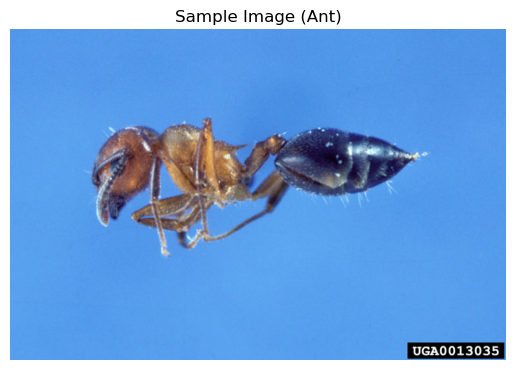

In [10]:
# STEP 4: Display one sample image
sample_path = os.path.join(ants_path, ants[0])
img = Image.open(sample_path)

print("Original image size:", img.size)

plt.imshow(img)
plt.title("Sample Image (Ant)")
plt.axis("off")
plt.show()


In [11]:
# STEP 7: Resize all images to 128x128

target_size = (128, 128)
print("Resizing images to:", target_size)

images = []
labels = []

for folder, label in [(ants_path, 0), (bees_path, 1)]:
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        
        try:
            img = Image.open(file_path).convert("RGB")
            img = img.resize(target_size)
            images.append(np.array(img))
            labels.append(label)
        except Exception as e:
            print("Error processing:", file_path, "| Error:", e)

print("Resizing complete!")
print("Total images:", len(images))
print("Total labels:", len(labels))


Resizing images to: (128, 128)
Resizing complete!
Total images: 245
Total labels: 245


In [12]:
def show_samples(paths, title):
    plt.figure(figsize=(10,5))
    plt.suptitle(title, fontsize=16)

    for i in range(6):
        img = Image.open(paths[i])
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

show_samples(ant_files, "Original Ant Images")
show_samples(bee_files, "Original Bee Images")


NameError: name 'ant_files' is not defined

In [13]:
%whos


Variable       Type              Data/Info
------------------------------------------
Image          module            <module 'PIL.Image' from <...>packages\\PIL\\Image.py'>
ants           list              n=124
ants_path      str               hymenoptera_data/train\ants
bees           list              n=121
bees_path      str               hymenoptera_data/train\bees
chunk          bytes             b'61c326481.jpgUX\x08\x00<...>\xc0\xdb\xd0\x02\x00\x00'
f              BufferedWriter    <_io.BufferedWriter name='hymenoptera_data.zip'>
file           str               98391118_bdb1e80cce.jpg
file_path      str               hymenoptera_data/train\be<...>s\98391118_bdb1e80cce.jpg
folder         str               hymenoptera_data/train\bees
images         list              n=245
img            Image             <PIL.Image.Image image mo<...>128x128 at 0x236EACDD700>
label          int               1
labels         list              n=245
np             module            <module 'num

In [14]:
# FIX: Create full file paths for ants and bees
ant_files = [os.path.join(ants_path, f) for f in ants]
bee_files = [os.path.join(bees_path, f) for f in bees]

print("Ant paths:", len(ant_files))
print("Bee paths:", len(bee_files))


Ant paths: 124
Bee paths: 121


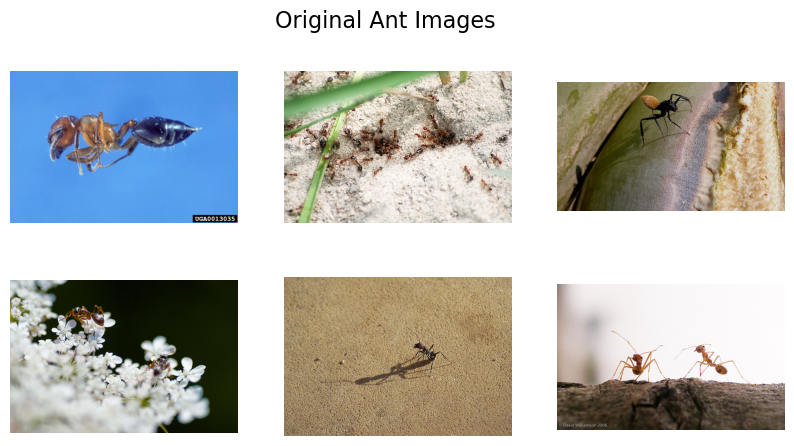

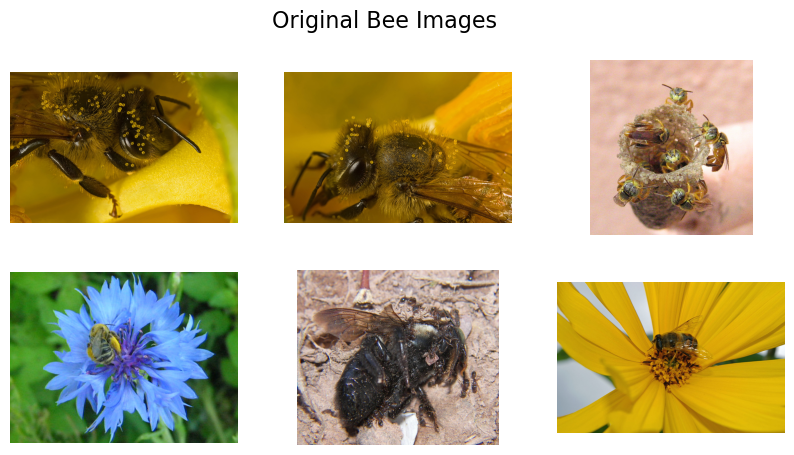

In [15]:
show_samples(ant_files, "Original Ant Images")
show_samples(bee_files, "Original Bee Images")


In [16]:
!pip install opencv-python


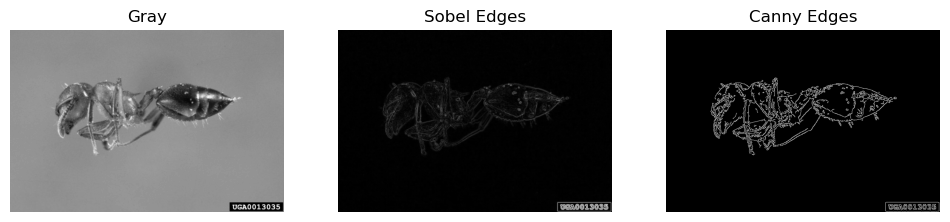

In [17]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Convert first ant image to grayscale
img = cv2.imread(ant_files[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Sobel edges
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
sobel_edges = cv2.magnitude(sobel_x, sobel_y)

# Canny edges
canny_edges = cv2.Canny(gray, 80, 200)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1); plt.title("Gray"); plt.imshow(gray, cmap='gray'); plt.axis("off")
plt.subplot(1,3,2); plt.title("Sobel Edges"); plt.imshow(sobel_edges, cmap='gray'); plt.axis("off")
plt.subplot(1,3,3); plt.title("Canny Edges"); plt.imshow(canny_edges, cmap='gray'); plt.axis("off")

plt.show()


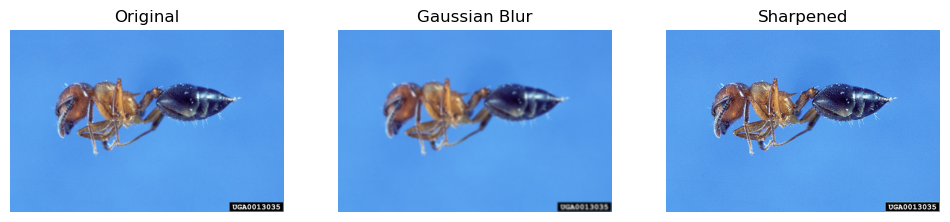

In [18]:
blurred = cv2.GaussianBlur(img, (9,9), 2)

# Sharpen filter kernel
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(img, -1, kernel)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,3,2); plt.title("Gaussian Blur"); plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,3,3); plt.title("Sharpened"); plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()


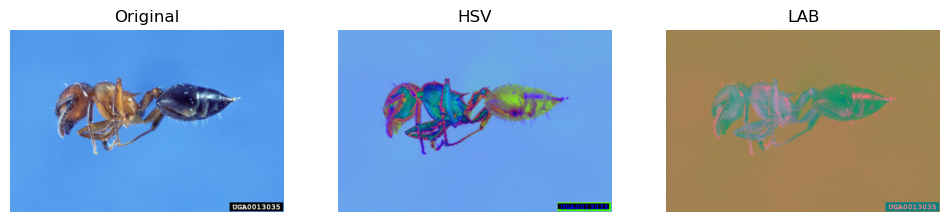

In [19]:
# Convert BGR -> HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Convert BGR -> LAB
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,3,2); plt.title("HSV"); plt.imshow(hsv); plt.axis("off")
plt.subplot(1,3,3); plt.title("LAB"); plt.imshow(lab); plt.axis("off")
plt.show()


In [20]:
from sklearn.decomposition import PCA

img_array = X_norm[0].reshape(-1, 3)  # flatten HxWx3 → (16384, 3)

pca = PCA(n_components=3)
compressed = pca.fit_transform(img_array)

reconstructed = pca.inverse_transform(compressed).reshape(128,128,3)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(X_norm[0]); plt.axis("off")
plt.subplot(1,2,2); plt.title("PCA Reconstructed"); plt.imshow(reconstructed); plt.axis("off")
plt.show()


NameError: name 'X_norm' is not defined

In [21]:
%whos


Variable       Type              Data/Info
------------------------------------------
Image          module            <module 'PIL.Image' from <...>packages\\PIL\\Image.py'>
PCA            ABCMeta           <class 'sklearn.decomposition._pca.PCA'>
ant_files      list              n=124
ants           list              n=124
ants_path      str               hymenoptera_data/train\ants
bee_files      list              n=121
bees           list              n=121
bees_path      str               hymenoptera_data/train\bees
blurred        ndarray           512x768x3: 1179648 elems, type `uint8`, 1179648 bytes (1.125 Mb)
canny_edges    ndarray           512x768: 393216 elems, type `uint8`, 393216 bytes (384.0 kb)
chunk          bytes             b'61c326481.jpgUX\x08\x00<...>\xc0\xdb\xd0\x02\x00\x00'
cv2            module            <module 'cv2' from 'C:\\U<...>kages\\cv2\\__init__.py'>
f              BufferedWriter    <_io.BufferedWriter name='hymenoptera_data.zip'>
file           str   

In [22]:
import numpy as np

# X must be a numpy array, so convert it (images is your resized list)
X = np.array(images)

print("X shape:", X.shape)   # should be (number_of_images, 128, 128, 3)

# normalize to 0–1
X_norm = X / 255.0

print("X_norm created successfully!")
print("X_norm shape:", X_norm.shape)
print("Sample pixel before normalization:", X[0][0][0])
print("Sample pixel after normalization:", X_norm[0][0][0])


X shape: (245, 128, 128, 3)
X_norm created successfully!
X_norm shape: (245, 128, 128, 3)
Sample pixel before normalization: [ 81 152 234]
Sample pixel after normalization: [0.31764706 0.59607843 0.91764706]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.440892098500626e-16..1.0].


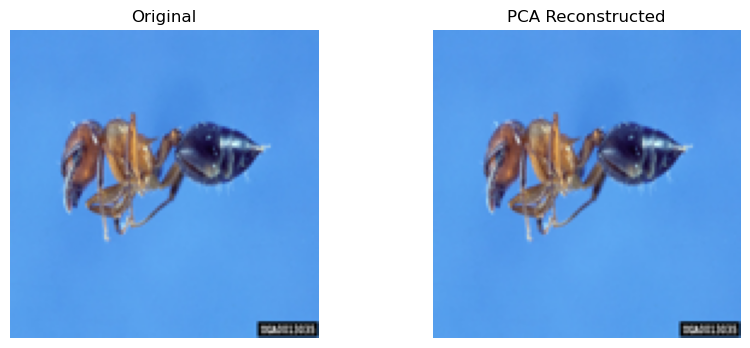

In [23]:
from sklearn.decomposition import PCA

img_array = X_norm[0].reshape(-1, 3)

pca = PCA(n_components=3)
compressed = pca.fit_transform(img_array)

reconstructed = pca.inverse_transform(compressed).reshape(128, 128, 3)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(X_norm[0]); plt.axis("off")
plt.subplot(1,2,2); plt.title("PCA Reconstructed"); plt.imshow(reconstructed); plt.axis("off")
plt.show()


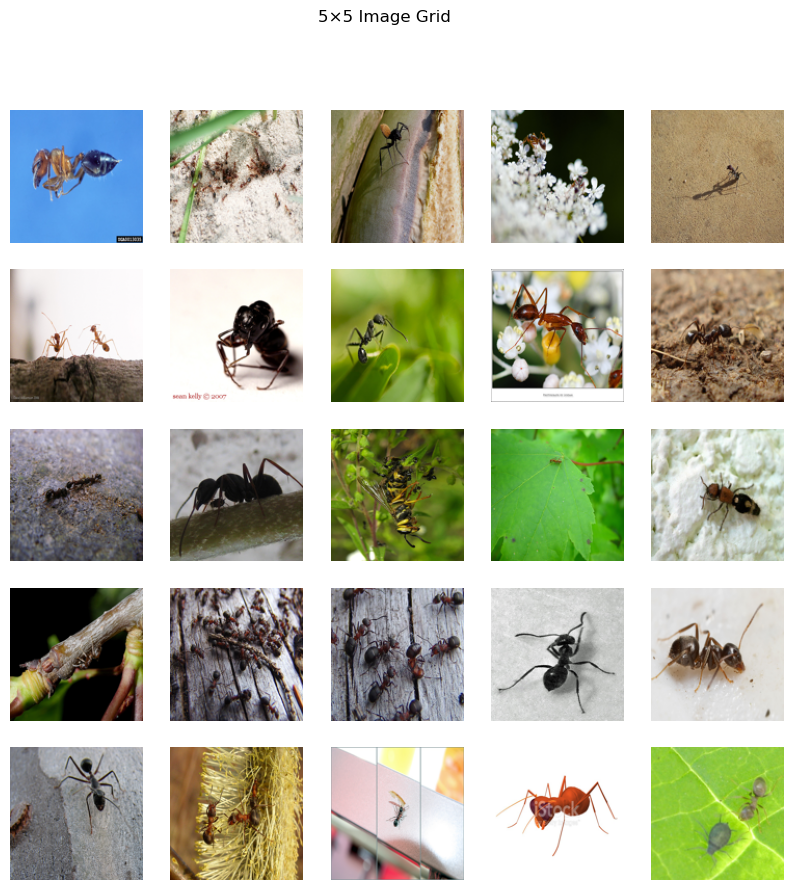

In [24]:
plt.figure(figsize=(10,10))
plt.suptitle("5×5 Image Grid")

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_norm[i])
    plt.axis("off")

plt.show()


In [27]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.8.0%2Bcpu-cp39-cp39-win_amd64.whl.metadata (7.4 kB)
Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.8.0%2Bcpu-cp39-cp39-win_amd64.whl (2.5 MB)


In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class AntBeeDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.fromarray((self.images[idx]*255).astype(np.uint8))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

dataset = AntBeeDataset(X_norm, labels, transform)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset ready!")


Dataset ready!


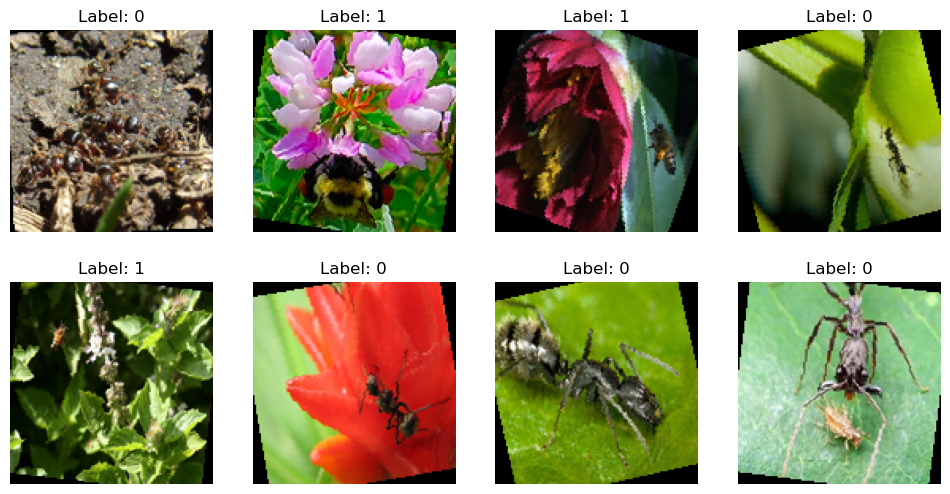

In [29]:
batch, lbl = next(iter(loader))

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(batch[i].permute(1,2,0))
    plt.title("Label: " + str(lbl[i].item()))
    plt.axis("off")

plt.show()


In [31]:
correct = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
print("✔ Successfully converted to HSV")


✔ Successfully converted to HSV


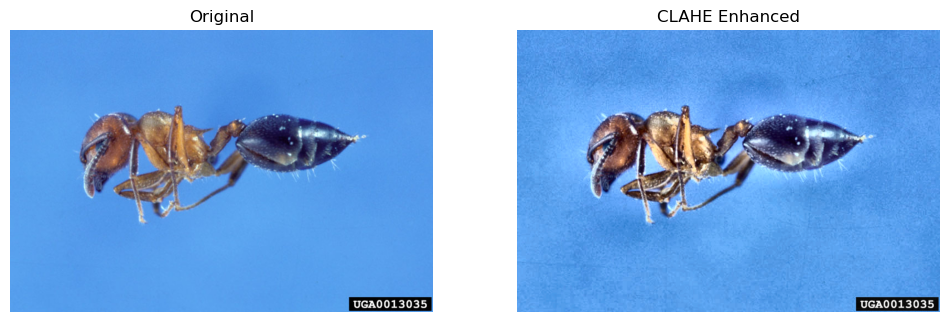

In [32]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread(ant_files[0])
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
cl = clahe.apply(l)

merged = cv2.merge((cl, a, b))
clahe_result = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,2,2); plt.title("CLAHE Enhanced"); plt.imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()


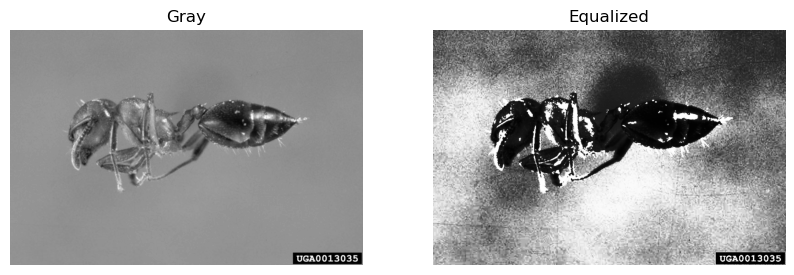

In [33]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Gray"); plt.imshow(gray, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("Equalized"); plt.imshow(equalized, cmap="gray"); plt.axis("off")
plt.show()


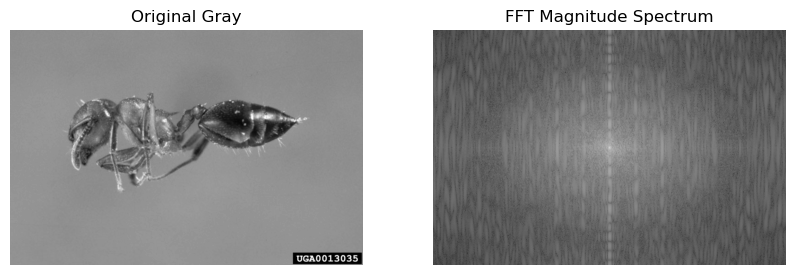

In [34]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)

magnitude = 20 * np.log(np.abs(fshift))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Original Gray"); plt.imshow(gray, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("FFT Magnitude Spectrum"); plt.imshow(magnitude, cmap="gray"); plt.axis("off")
plt.show()


In [ ]:
Z = img.reshape((-1,3))
Z = np.float32(Z)

k = 3  # number of clusters
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, labels, centers = cv2.kmeans(Z, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

segmented = centers[labels.flatten()].reshape(img.shape)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,2,2); plt.title(f"K-Means Segmentation (k={k})"); plt.imshow(segmented.astype(np.uint8)); plt.axis("off")
plt.show()


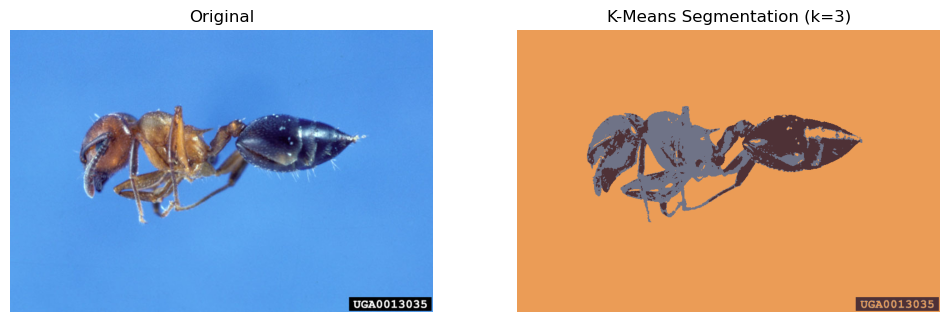

In [35]:
Z = img.reshape((-1,3))
Z = np.float32(Z)

k = 3  # number of clusters
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, labels, centers = cv2.kmeans(Z, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

segmented = centers[labels.flatten()].reshape(img.shape)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,2,2); plt.title(f"K-Means Segmentation (k={k})"); plt.imshow(segmented.astype(np.uint8)); plt.axis("off")
plt.show()


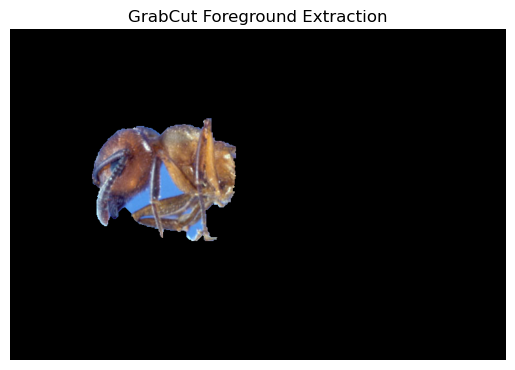

In [36]:
mask = np.zeros(img.shape[:2], np.uint8)
bgModel = np.zeros((1,65), np.float64)
fgModel = np.zeros((1,65), np.float64)

rect = (50, 50, 300, 300)

cv2.grabCut(img, mask, rect, bgModel, fgModel, 5, cv2.GC_INIT_WITH_RECT)

mask2 = np.where((mask==2)|(mask==0), 0, 1).astype("uint8")
grabcut = img * mask2[:, :, np.newaxis]

plt.imshow(cv2.cvtColor(grabcut, cv2.COLOR_BGR2RGB))
plt.title("GrabCut Foreground Extraction")
plt.axis("off")
plt.show()


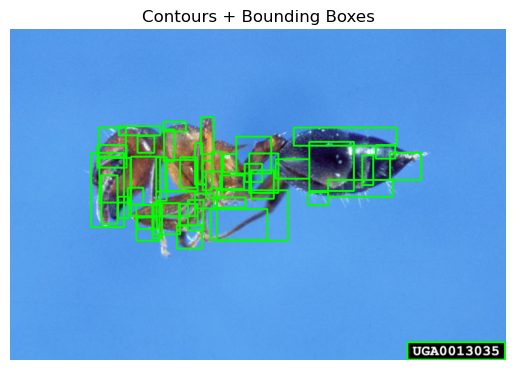

In [37]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 80, 200)

contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
boxed = img.copy()

for cnt in contours:
    x,y,w,h = cv2.boundingRect(cnt)
    if w*h > 500:  # filter small noise
        cv2.rectangle(boxed, (x,y), (x+w, y+h), (0,255,0), 2)

plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
plt.title("Contours + Bounding Boxes")
plt.axis("off")
plt.show()


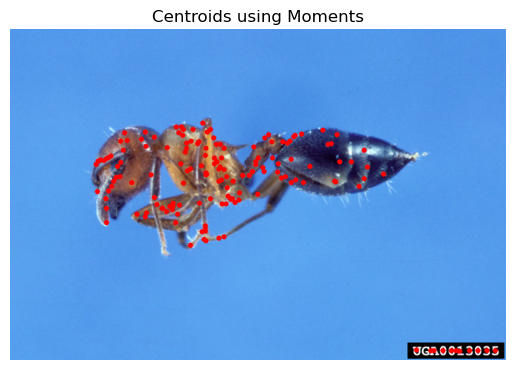

In [38]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
shape_img = img.copy()

for cnt in contours:
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"]/M["m00"])
        cy = int(M["m01"]/M["m00"])
        cv2.circle(shape_img, (cx,cy), 4, (0,0,255), -1)

plt.imshow(cv2.cvtColor(shape_img, cv2.COLOR_BGR2RGB))
plt.title("Centroids using Moments")
plt.axis("off")
plt.show()


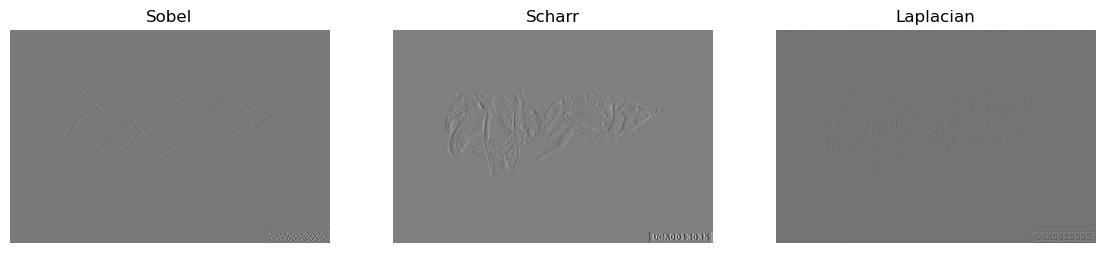

In [39]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobel = cv2.Sobel(gray, cv2.CV_64F, 1, 1)
scharr = cv2.Scharr(gray, cv2.CV_64F, 1, 0)
laplace = cv2.Laplacian(gray, cv2.CV_64F)

plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.title("Sobel"); plt.imshow(sobel, cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("Scharr"); plt.imshow(scharr, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Laplacian"); plt.imshow(laplace, cmap="gray"); plt.axis("off")
plt.show()


In [40]:
from skimage.feature import hog

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hog_features, hog_image = hog(gray, visualize=True)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(gray, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("HOG Features"); plt.imshow(hog_image, cmap="gray"); plt.axis("off")
plt.show()


ModuleNotFoundError: No module named 'skimage'

In [41]:
!pip install scikit-image


  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.9 MB 1.4 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/12.9 MB 1.3 MB/s eta 0:00:10
   --- ------------------------------------ 1.0/12.9 MB 1.3 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/12.9 MB 1.3 MB/s eta 0:00:09
   ---- ----------------------------------- 1.6/12.9 MB 1.3 MB/s eta 0:00:09
   ----- ---------------------------------- 1.8/12.9 MB 1.3 MB/s eta 0:00:09
   ------ --------------------------------- 2.1/12.9 MB 1.3 MB/s eta 0:00:09
   ------- -------------------------------- 2.4/12.9 MB 1.3 MB/s eta 0:00:09
   -------- ------------------------------- 2.6/12.9 MB 1.3 MB/s eta 0:00:08
   -------- ------------------------

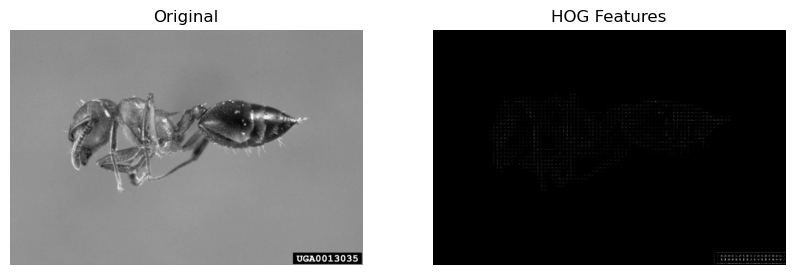

In [42]:
from skimage.feature import hog

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hog_features, hog_image = hog(gray, visualize=True)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(gray, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("HOG Features"); plt.imshow(hog_image, cmap="gray"); plt.axis("off")
plt.show()


In [43]:
from skimage.feature import graycomatrix, graycoprops

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

glcm = graycomatrix(gray, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)

contrast = graycoprops(glcm, 'contrast')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

print("GLCM Contrast:", contrast)
print("GLCM Energy:", energy)
print("GLCM Homogeneity:", homogeneity)


GLCM Contrast: 317.22549762450853
GLCM Energy: 0.08939435156748426
GLCM Homogeneity: 0.4211146855125887
